# Predictive Maintenance and Anomaly Detection in Industrial Machinery.

## Questions:
1. For predictive maintenance, which machine-learning algorithms work best?

- To find the best dependable classifier, several models (Logistic Regression, XGBoost, Random Forest, Decision Tree) are compared.

2. Is it possible to anticipate machine faults before they happen?

- This investigates whether observable early-warning patterns can be found in operational variables like temperature, rotational speed, torque, or tool wear.

3. Which particular kind of failure is most likely to happen?

- The dataset allows for classification into many failure classes (such as Overstrain, Heat Dissipation Failure, etc.) in addition to basic Failure/No Failure prediction.

4. Do quantifiable anomalies exist in machine signals prior to failure?

- This examines whether patterns missed by supervised models can be highlighted by unsupervised anomaly-detection techniques like Isolation Forest and LOF.

## Goal:
The goal is to predict maintenance and monitor anomaly to prevent the down-time and cost for the machinery to keep continue the flow.

## Dataset:
- The selected dataset has five distinct failure categories and a binary failure target, it is suitable for supervised learning tasks and predictive maintenance research. It makes it possible to analyze operating trends and equipment behavior in a meaningful way by providing realistic machine sensor readings, such as temperature, rotational speed, torque, and tool wear. Additionally, the collection contains natural outliers, which are not noise but rather actual industrial anomalies and provide important information for defect diagnosis. Even though the data is fairly balanced, SMOTE oversampling helps to increase model resilience and handle modest class distribution concerns. This dataset facilitates benchmarking and comparison with results from the current literature since it is frequently utilized in predictive maintenance studies.
- https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

In [7]:
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import LocalOutlierFactor

# Load the dataset
# ------------------------------
df = pd.read_csv("predictive_maintenance.csv")

Understanding the structure and behavior of the dataset is crucial before creating predictive maintenance models. By looking at summary statistics, displaying feature distributions, verifying class imbalance, and investigating connections between failures and machine parameters, this EDA segment gives an overview of the sensor readings and operational conditions. These insights provide a strong basis for developing precise binary and multi-class machine failure prediction models by assisting in the identification of patterns, anomalies, and preprocessing requirements.

Following actions have been performed in this section:
- Presenting the dataset overview, structure, and initial few rows
- Analyzing fundamental data on temperature, torque, speed, and tool wear
- Visualizing distributions to identify anomalous numbers or skewness
- Examining the failure categories' distribution
- Creating correlation heatmaps to comprehend how numerical variables relate to one another
- Comparing failure kinds with sensor features using boxplots
- Finding outliers and determining if they are actual machine anomalies

First 5 rows of the dataset


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


------------------------------
Description of the dataset
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]        Target  
count            10000.000000  10000.000000     10000.000000  10000.000000  
mean              1538.776100     39.986910       107.951000      0.033900  
std                179.284096      9.968934        63.654147      0.180981  
min               116

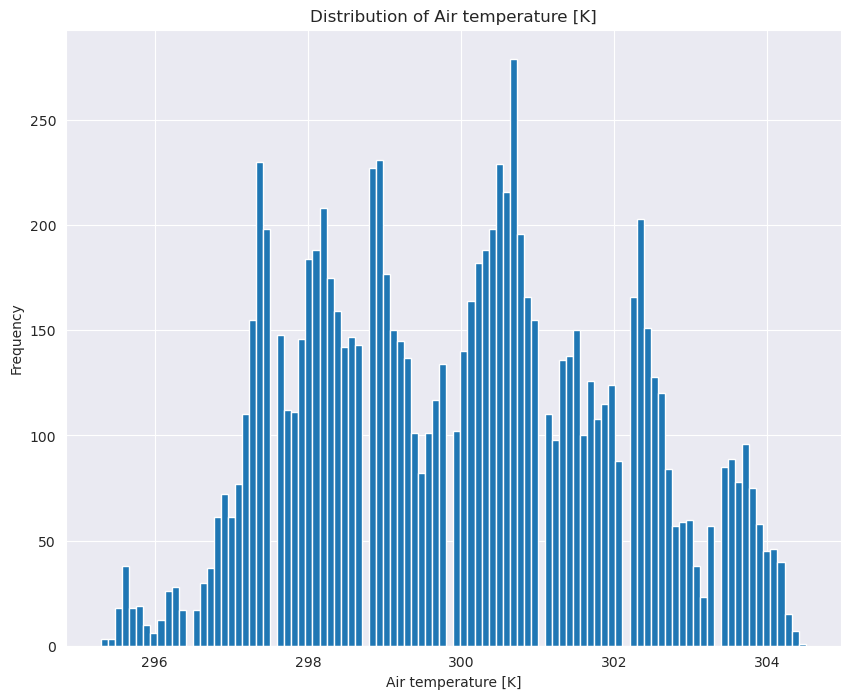

------------------------------
Distribution mean of Process temperature [K]: 310.00556
------------------------------
Distribution median of Process temperature [K]: 310.1
------------------------------
Standard diviation of Process temperature [K]: 1.4837342191657419
------------------------------
Distribution of Process temperature [K]


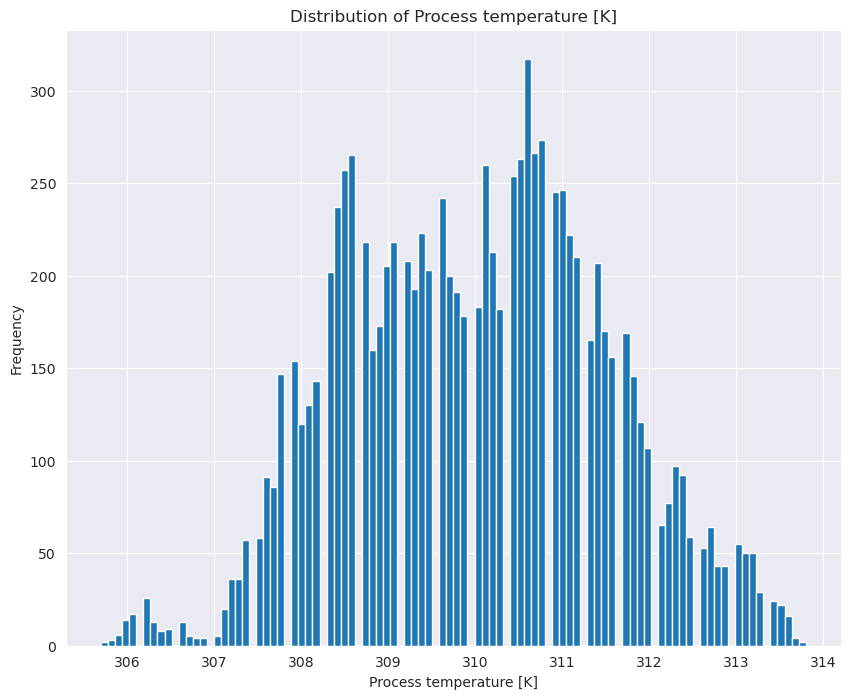

------------------------------
Distribution mean of Rotational speed [rpm]: 1538.7761
------------------------------
Distribution median of Rotational speed [rpm]: 1503.0
------------------------------
Standard diviation of Rotational speed [rpm]: 179.28409591342628
------------------------------
Distribution of Rotational speed [rpm]


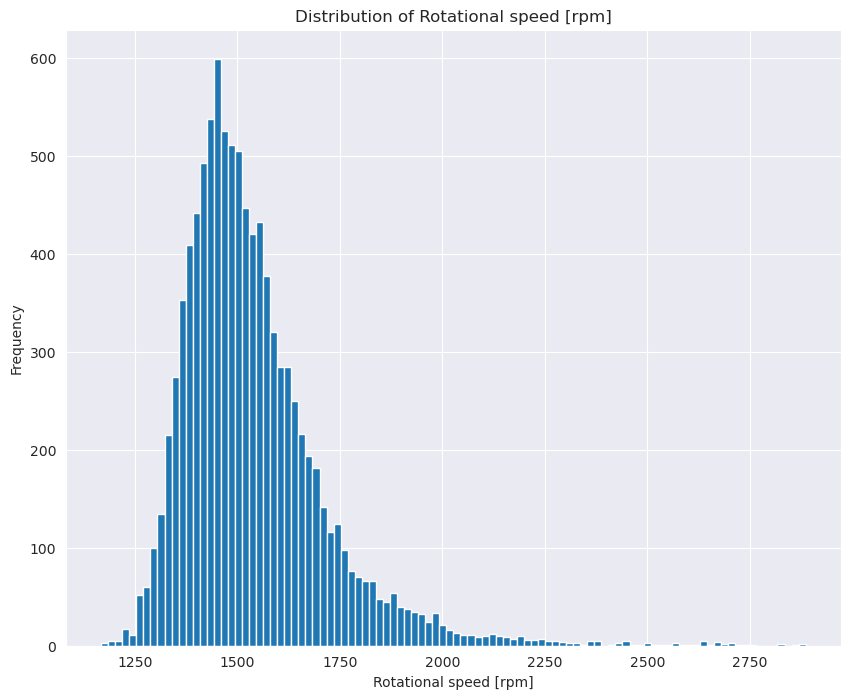

------------------------------
Distribution mean of Torque [Nm]: 39.986909999999995
------------------------------
Distribution median of Torque [Nm]: 40.1
------------------------------
Standard diviation of Torque [Nm]: 9.968933725121401
------------------------------
Distribution of Torque [Nm]


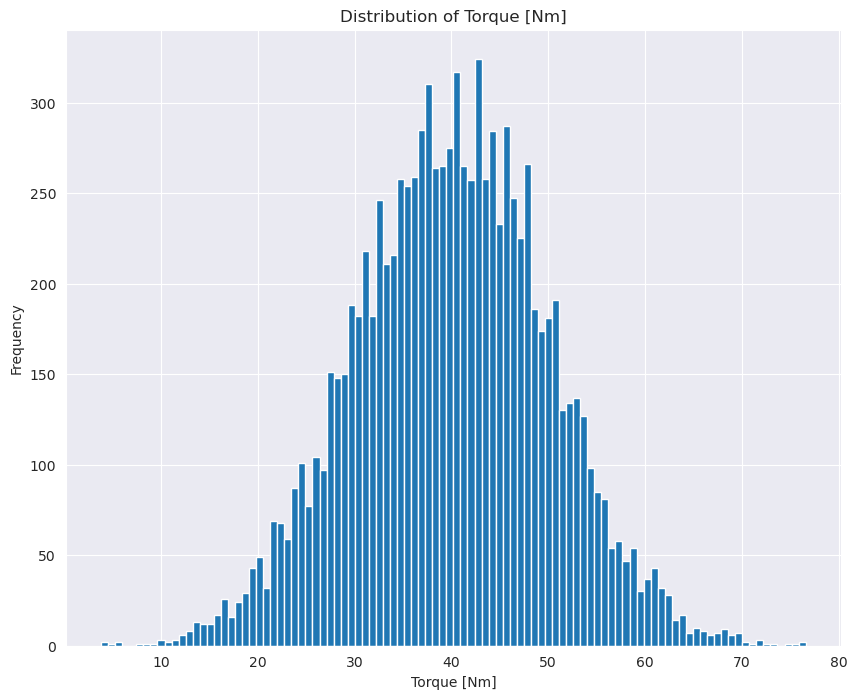

------------------------------
Distribution mean of Tool wear [min]: 107.951
------------------------------
Distribution median of Tool wear [min]: 108.0
------------------------------
Standard diviation of Tool wear [min]: 63.65414663663639
------------------------------
Distribution of Tool wear [min]


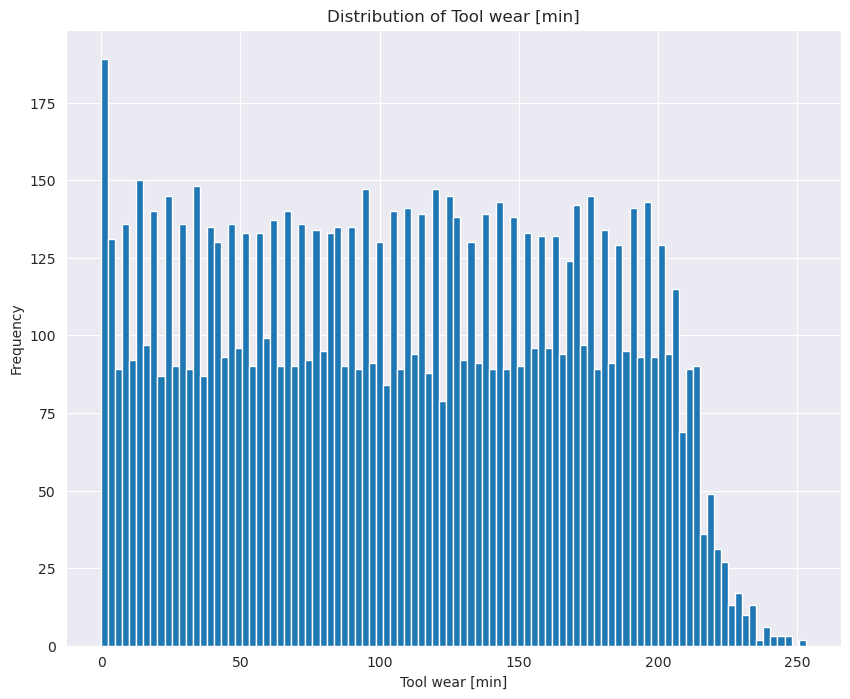

------------------------------
Class distribution of Failure type
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64
------------------------------
Class distribution of Failure type in percentage
Failure Type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64
------------------------------
Visualization of Failure type


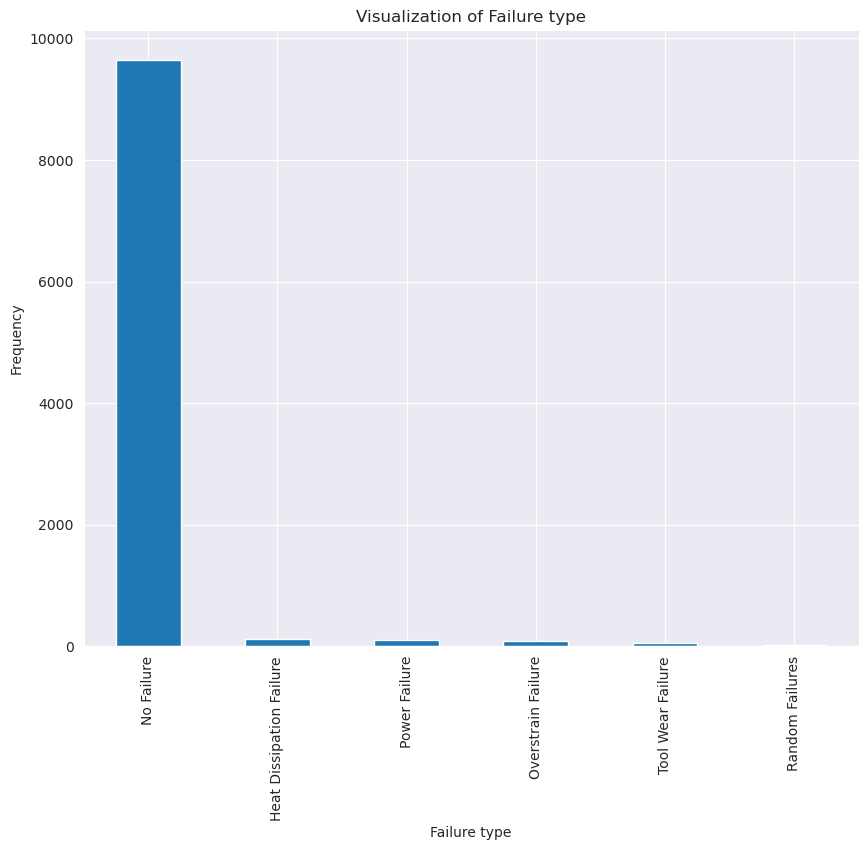

------------------------------
Correlation matrix


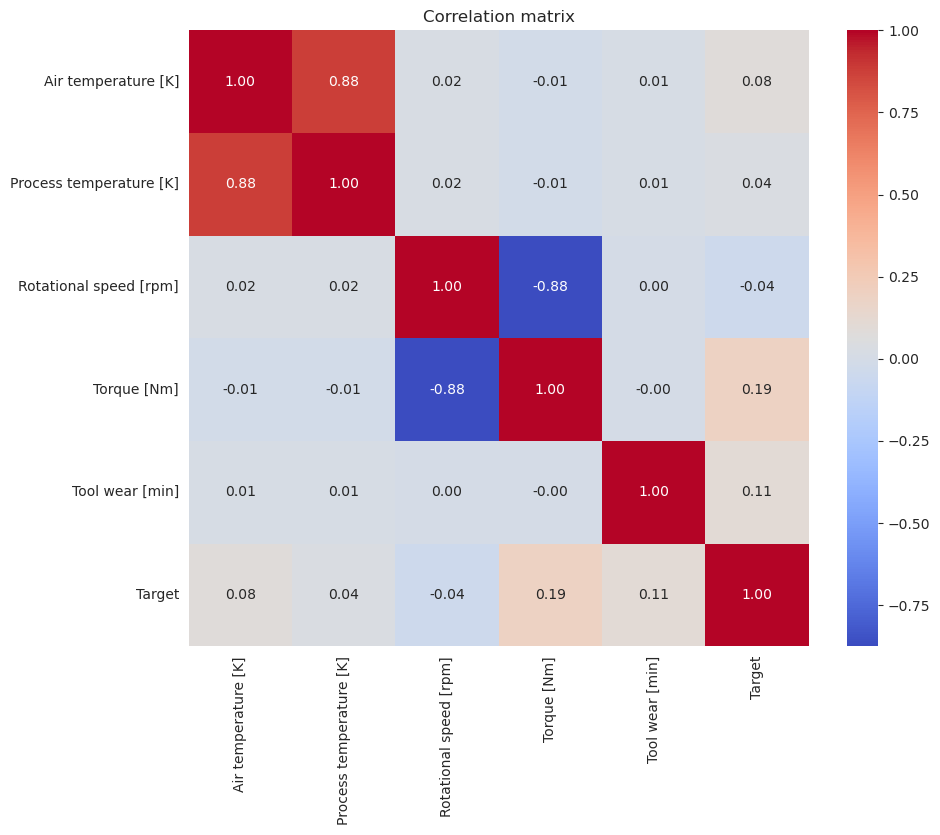

------------------------------
Relationship between Air temperature [K] and Failure Type


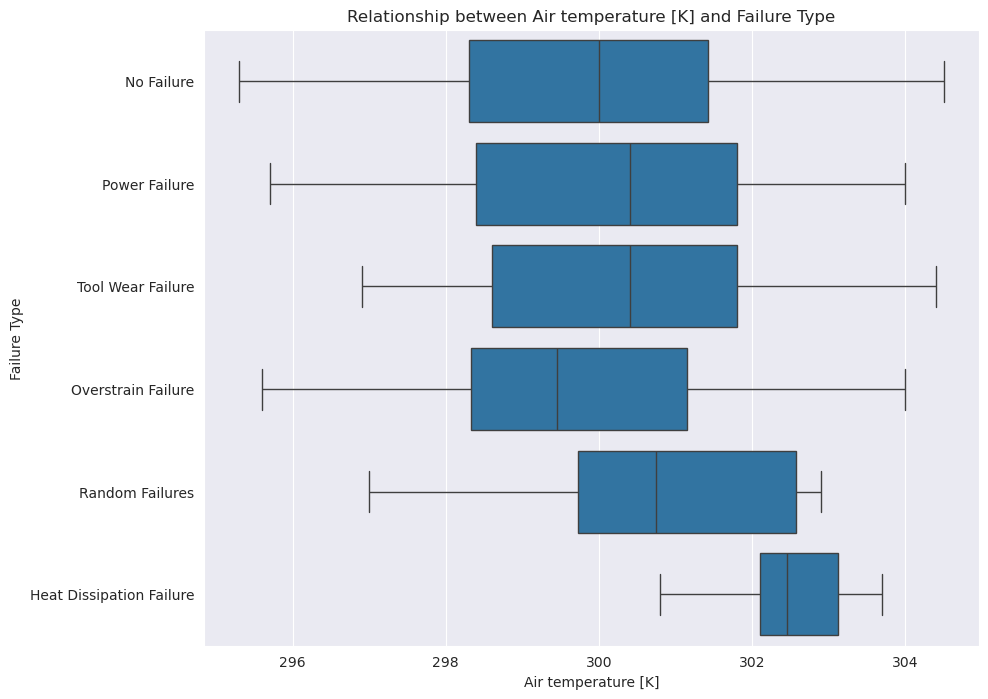

------------------------------
Relationship between Process temperature [K] and Failure Type


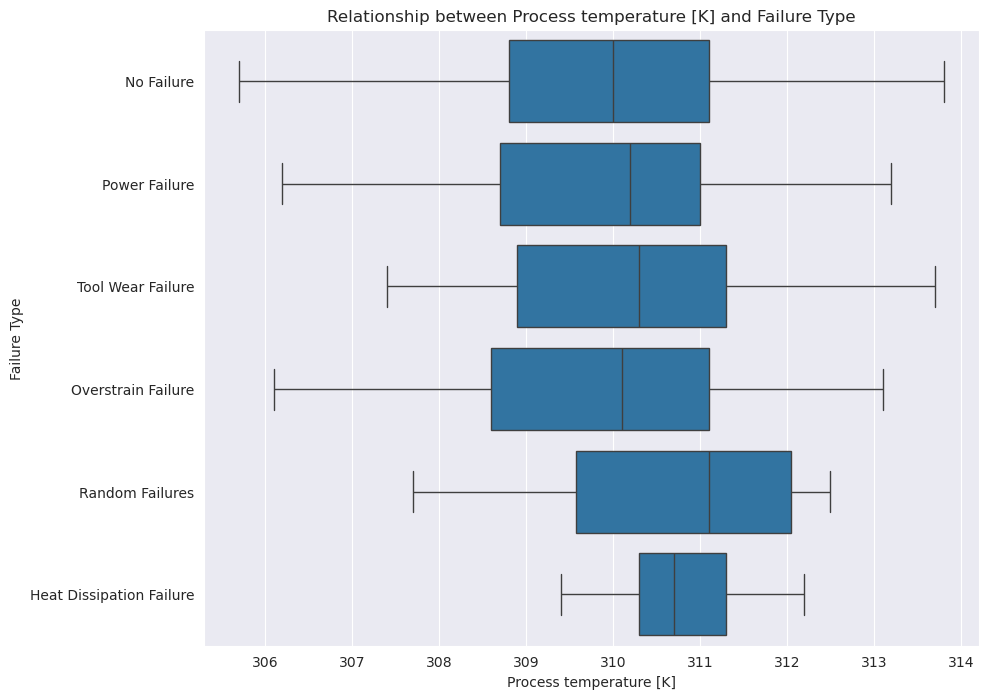

------------------------------
Relationship between Rotational speed [rpm] and Failure Type


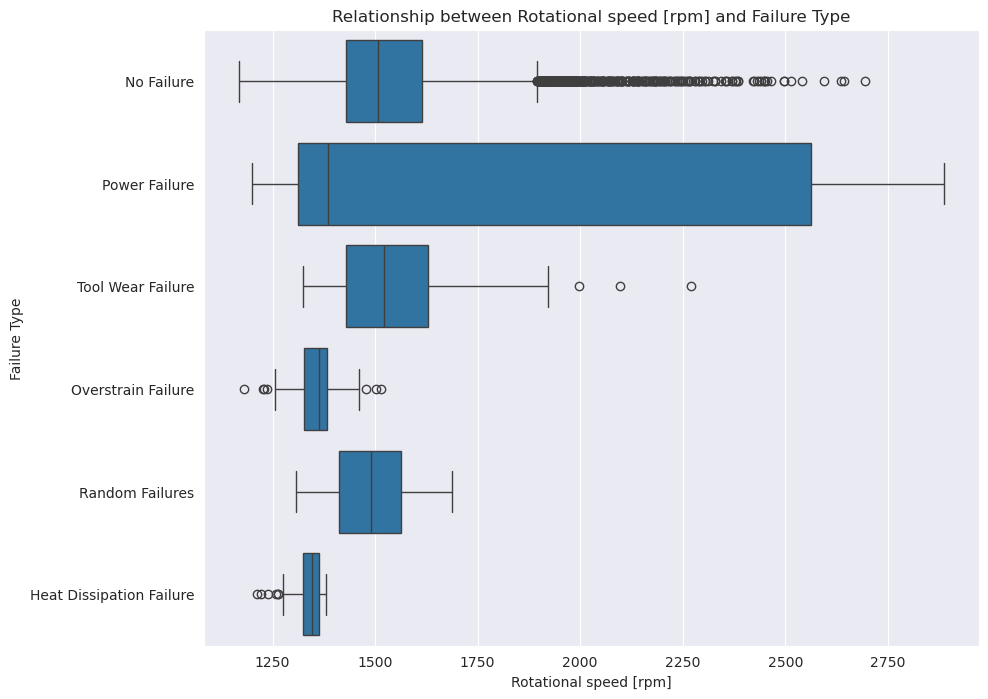

------------------------------
Relationship between Torque [Nm] and Failure Type


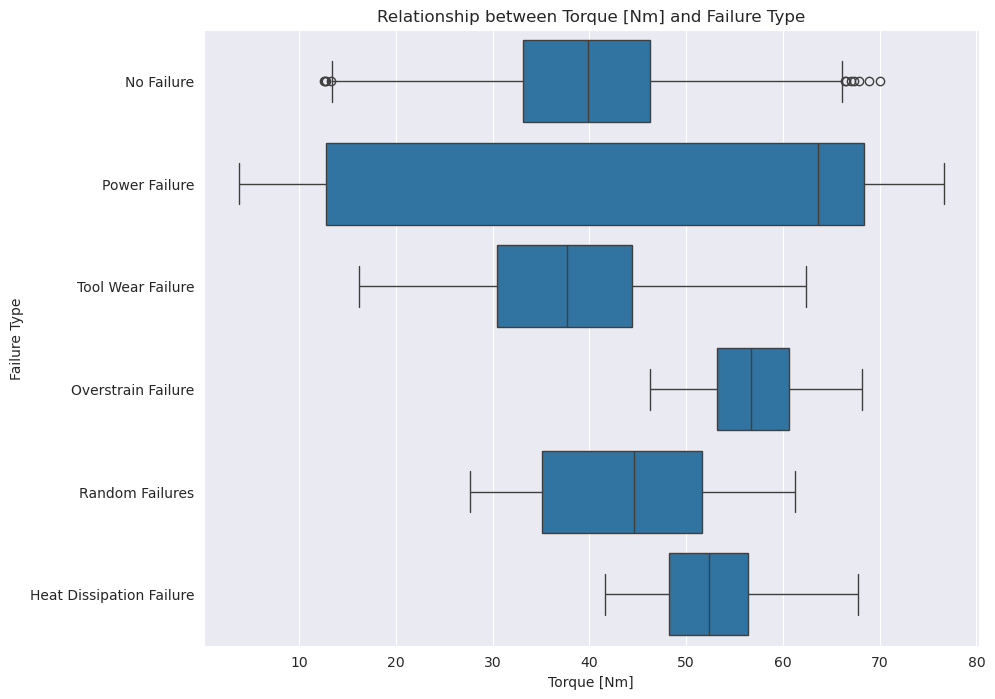

------------------------------
Relationship between Tool wear [min] and Failure Type


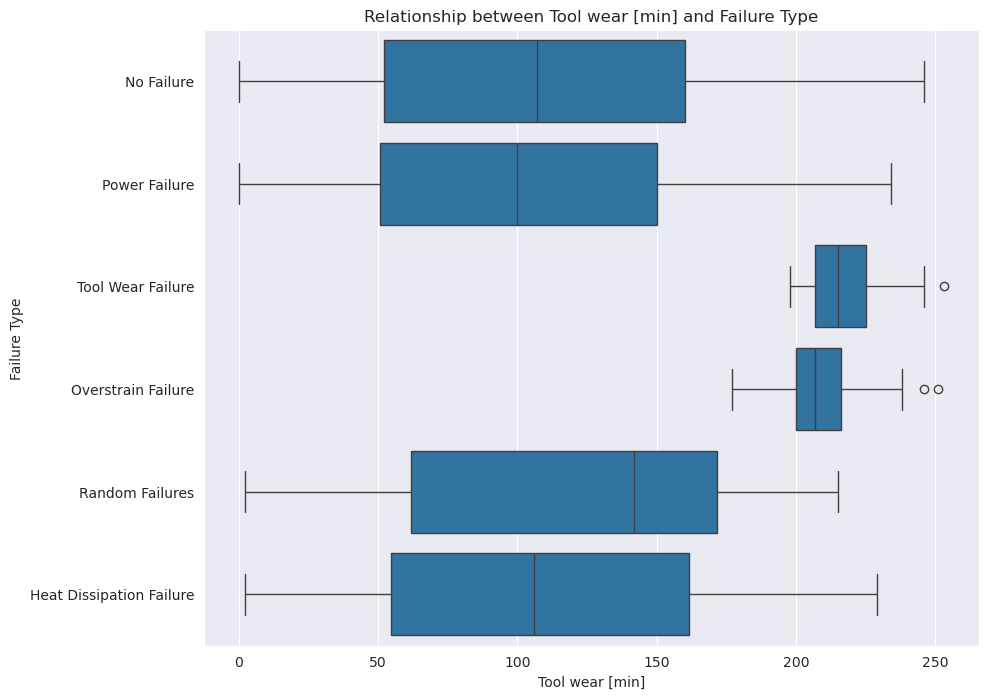

------------------------------


In [8]:
# Exploratory Data Analysis (EDA)

# Display the dataset
# ------------------------------
print("First 5 rows of the dataset")
display(df.head())
print("------------------------------")
print("Description of the dataset")
print(df.describe())
print("------------------------------")
print("Information about the dataset")
print(df.info())
print("------------------------------")
print("Shape of the dataset")
print(df.shape)
print("------------------------------")

# Feature analysis
# ------------------------------
# Statistics of Air temperature [K]
print("Distribution mean of Air temperature [K]:", df["Air temperature [K]"].mean())
print("------------------------------")
print("Distribution median of Air temperature [K]:", df["Air temperature [K]"].median())
print("------------------------------")
print("Standard diviation of Air temperature [K]:", df["Air temperature [K]"].std())
print("------------------------------")

# Distribution of Air temperature [K]
print("Distribution of Air temperature [K]")
plt.figure(figsize = (10, 8))
plt.hist(df["Air temperature [K]"], bins = 100)
plt.xlabel("Air temperature [K]")
plt.ylabel("Frequency")
plt.title("Distribution of Air temperature [K]")
plt.show()
print("------------------------------")

# Statistics of Process temperature [K]
print("Distribution mean of Process temperature [K]:", df["Process temperature [K]"].mean())
print("------------------------------")
print("Distribution median of Process temperature [K]:", df["Process temperature [K]"].median())
print("------------------------------")
print("Standard diviation of Process temperature [K]:", df["Process temperature [K]"].std())
print("------------------------------")

# Distribution of Process temperature [K]
print("Distribution of Process temperature [K]")
plt.figure(figsize = (10, 8))
plt.hist(df["Process temperature [K]"], bins = 100)
plt.xlabel("Process temperature [K]")
plt.ylabel("Frequency")
plt.title("Distribution of Process temperature [K]")
plt.show()
print("------------------------------")

# Statistics of Rotational speed [rpm]
print("Distribution mean of Rotational speed [rpm]:", df["Rotational speed [rpm]"].mean())
print("------------------------------")
print("Distribution median of Rotational speed [rpm]:", df["Rotational speed [rpm]"].median())
print("------------------------------")
print("Standard diviation of Rotational speed [rpm]:", df["Rotational speed [rpm]"].std())
print("------------------------------")

# Distribution of Rotational speed [rpm]
print("Distribution of Rotational speed [rpm]")
plt.figure(figsize = (10, 8))
plt.hist(df["Rotational speed [rpm]"], bins = 100)
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Frequency")
plt.title("Distribution of Rotational speed [rpm]")
plt.show()
print("------------------------------")

# Statistics of Torque [Nm]
print("Distribution mean of Torque [Nm]:", df["Torque [Nm]"].mean())
print("------------------------------")
print("Distribution median of Torque [Nm]:", df["Torque [Nm]"].median())
print("------------------------------")
print("Standard diviation of Torque [Nm]:", df["Torque [Nm]"].std())
print("------------------------------")

# Distribution of Torque [Nm]
print("Distribution of Torque [Nm]")
plt.figure(figsize = (10, 8))
plt.hist(df["Torque [Nm]"], bins = 100)
plt.xlabel("Torque [Nm]")
plt.ylabel("Frequency")
plt.title("Distribution of Torque [Nm]")
plt.show()
print("------------------------------")

# Statistics of Tool wear [min]
print("Distribution mean of Tool wear [min]:", df["Tool wear [min]"].mean())
print("------------------------------")
print("Distribution median of Tool wear [min]:", df["Tool wear [min]"].median())
print("------------------------------")
print("Standard diviation of Tool wear [min]:", df["Tool wear [min]"].std())
print("------------------------------")

# Distribution of Tool wear [min]
print("Distribution of Tool wear [min]")
plt.figure(figsize = (10, 8))
plt.hist(df["Tool wear [min]"], bins = 100)
plt.xlabel("Tool wear [min]")
plt.ylabel("Frequency")
plt.title("Distribution of Tool wear [min]")
plt.show()
print("------------------------------")

# Class distribution of Failure type
print("Class distribution of Failure type")
print(df["Failure Type"].value_counts())
print("------------------------------")
print("Class distribution of Failure type in percentage")
print(df["Failure Type"].value_counts(normalize = True) * 100)
print("------------------------------")

# Visualization of Failure type
print("Visualization of Failure type")
plt.figure(figsize = (10, 8))
df["Failure Type"].value_counts().plot(kind = "bar")
plt.xlabel("Failure type")
plt.ylabel("Frequency")
plt.title("Visualization of Failure type")
plt.show()
print("------------------------------")

# Relationships and correlation between features
# ------------------------------
print("Correlation matrix")
plt.figure(figsize = (10, 8))
sn.heatmap(df.drop(["UDI", "Product ID", "Type", "Failure Type"], axis = 1).corr(), annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlation matrix")
plt.show()
print("------------------------------")

# Visualizing the relationships between the Failure Type with other features
print("Relationship between Air temperature [K] and Failure Type")
plt.figure(figsize = (10, 8))
sn.boxplot(x = "Air temperature [K]", y = "Failure Type", data = df)
plt.xlabel("Air temperature [K]")
plt.ylabel("Failure Type")
plt.title("Relationship between Air temperature [K] and Failure Type")
plt.show()
print("------------------------------")

print("Relationship between Process temperature [K] and Failure Type")
plt.figure(figsize = (10, 8))
sn.boxplot(x = "Process temperature [K]", y = "Failure Type", data = df)
plt.xlabel("Process temperature [K]")
plt.ylabel("Failure Type")
plt.title("Relationship between Process temperature [K] and Failure Type")
plt.show()
print("------------------------------")

print("Relationship between Rotational speed [rpm] and Failure Type")
plt.figure(figsize = (10, 8))
sn.boxplot(x = "Rotational speed [rpm]", y = "Failure Type", data = df)
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Failure Type")
plt.title("Relationship between Rotational speed [rpm] and Failure Type")
plt.show()
print("------------------------------")

print("Relationship between Torque [Nm] and Failure Type")
plt.figure(figsize = (10, 8))
sn.boxplot(x = "Torque [Nm]", y = "Failure Type", data = df)
plt.xlabel("Torque [Nm]")
plt.ylabel("Failure Type")
plt.title("Relationship between Torque [Nm] and Failure Type")
plt.show()
print("------------------------------")

print("Relationship between Tool wear [min] and Failure Type")
plt.figure(figsize = (10, 8))
sn.boxplot(x = "Tool wear [min]", y = "Failure Type", data = df)
plt.xlabel("Tool wear [min]")
plt.ylabel("Failure Type")
plt.title("Relationship between Tool wear [min] and Failure Type")
plt.show()
print("------------------------------")

By resolving duplicates, eliminating unnecessary columns, and inspection of missing values and outliers, the first steps concentrated on guaranteeing data quality. The data was then prepared for two different machine learning tasks: binary classification (predicting a failure occurred) and multi-class classification (predicting the type of failure).

Following actions have been performed in this section:
- Check for Missing Values
- Remove Irrelevant Columns
- Check for Duplicates
- Outlier Inspection
- Data Type Correction
- Feature and Target Separation
- Feature Encoding/Transformation
- Data Splitting

Missing values in the dataset
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64
------------------------------
Dataset after drop the irrelevant columns


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


------------------------------
Duplicated records in the dataset
0
------------------------------
Data types of the dataset
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object
------------------------------
Data types of the dataset after fix
Type                       category
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Target                        int64
Failure Type               category
dtype: object
------------------------------


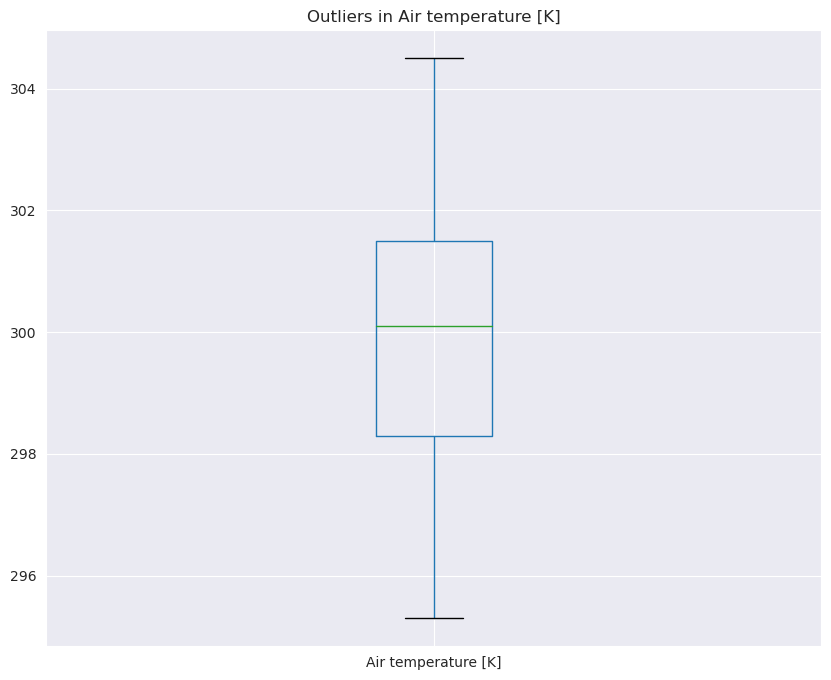

------------------------------


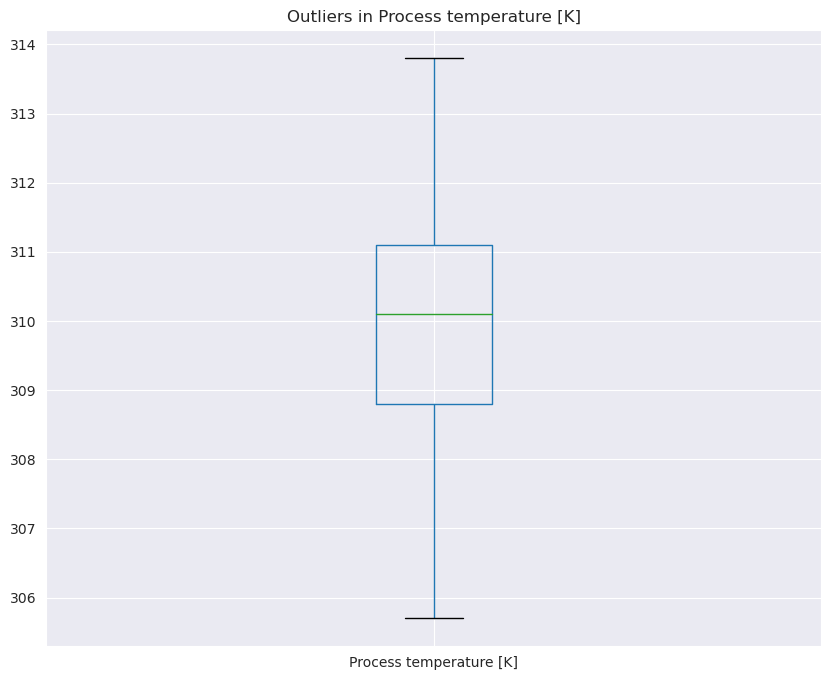

------------------------------


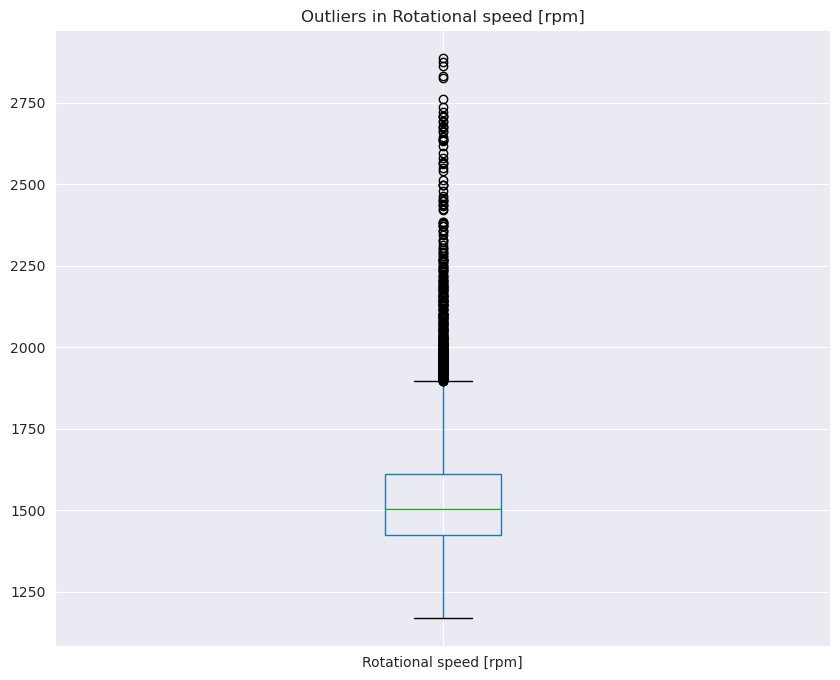

------------------------------


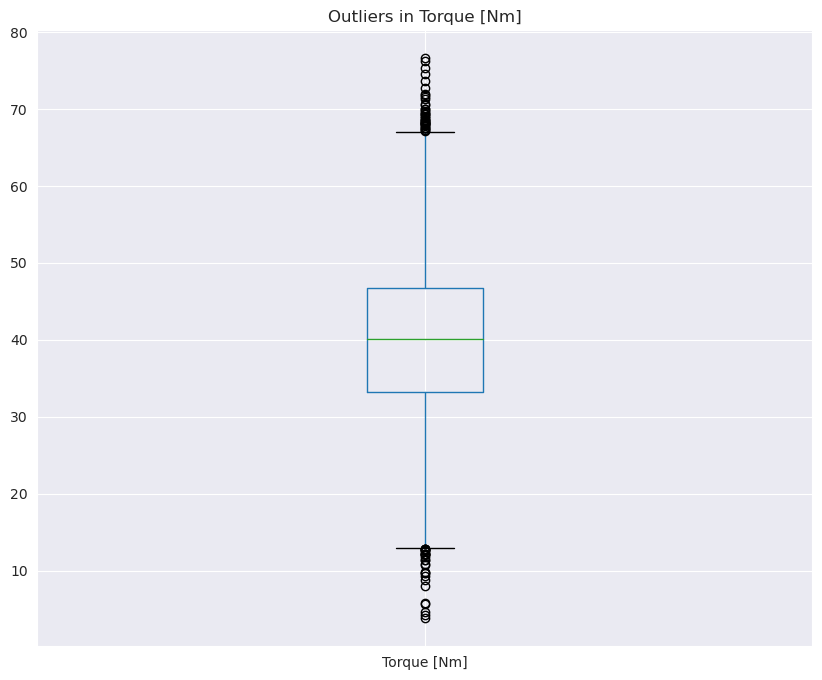

------------------------------


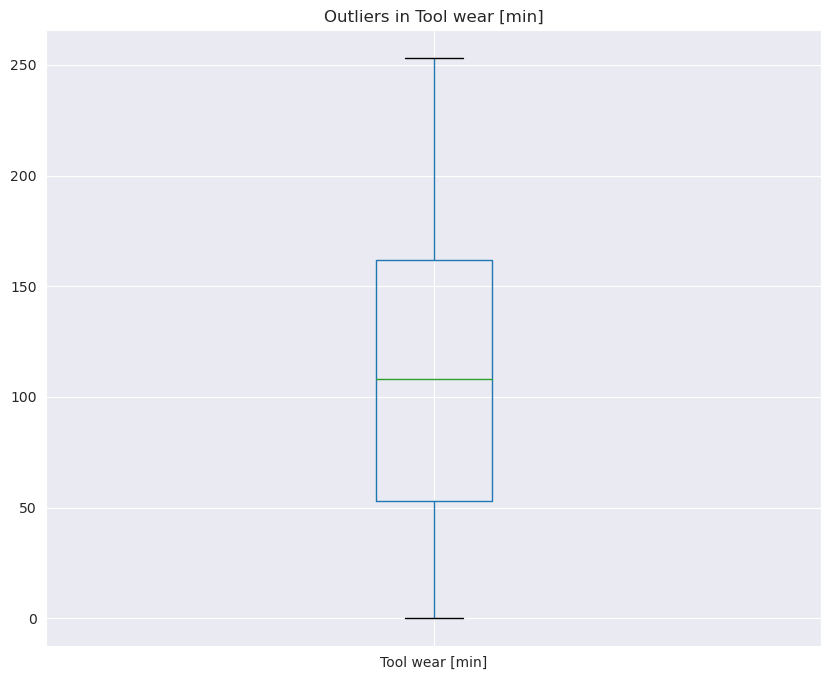

------------------------------


In [9]:
# Clean the dataset
# ------------------------------
# Inspection of missing values
print("Missing values in the dataset")
print(df.isnull().sum())
print("------------------------------")

# Drop irrelative columns
df = df.drop(["UDI", "Product ID"], axis = 1)
print("Dataset after drop the irrelevant columns")
display(df.head())
print("------------------------------")

# Remove duplicated records
print("Duplicated records in the dataset")
print(df.duplicated().sum())
print("------------------------------")

# Fix data types
print("Data types of the dataset")
print(df.dtypes)
print("------------------------------")
df["Type"] = df["Type"].astype("category")
df["Failure Type"] = df["Failure Type"].astype("category")
print("Data types of the dataset after fix")
print(df.dtypes)
print("------------------------------")

# Inspection of outliers
numerical_columns = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
for col in numerical_columns:
    plt.figure(figsize = (10, 8))
    df.boxplot(column = col)
    plt.title(f"Outliers in {col}")
    plt.show()
    print("------------------------------")
# Rotational speed [rpm], and Torque [Nm] data all showed outliers.
# Because they depict actual machine anomalies that could result in equipment failure, these outliers were retained in the dataset.

X = df.drop(["Failure Type", "Target"], axis = 1)
y_binary = df["Target"]
y_multi = df["Failure Type"]

# Split the dataset for both the models
X_train, X_test, y_train_binary, y_test_binary = train_test_split(X, y_binary, test_size = 0.25, stratify = y_binary)
_, _, y_train_multi, y_test_multi = train_test_split(X, y_multi, test_size = 0.25, stratify = y_multi)

# Encode catgeogrical data for binary models (Logistic Regression and XGBoost)
categorical_cols = ["Type"]
numerical_cols = [col for col in X.columns if col != "Type"]
preprocess_with_scaler = ColumnTransformer([
    ("cat", OneHotEncoder(drop = "first"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

# Encode catgeogrical data for multi-class classification models (Random Forest and Decision Tree)
preprocess_no_scaler = ColumnTransformer([
    ("cat", OneHotEncoder(drop = "first"), categorical_cols),
    ("num", "passthrough", numerical_cols)
])

Training and Assessment of Machine Learning Models

Following actions have been performed in this section:
- Building Pipelines
- Training and Assessing Models

Binary model (Logistic Regression) score: 0.8164
------------------------------
Binary model classification report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      2415
           1       0.12      0.73      0.21        85

    accuracy                           0.82      2500
   macro avg       0.56      0.77      0.55      2500
weighted avg       0.96      0.82      0.87      2500

------------------------------


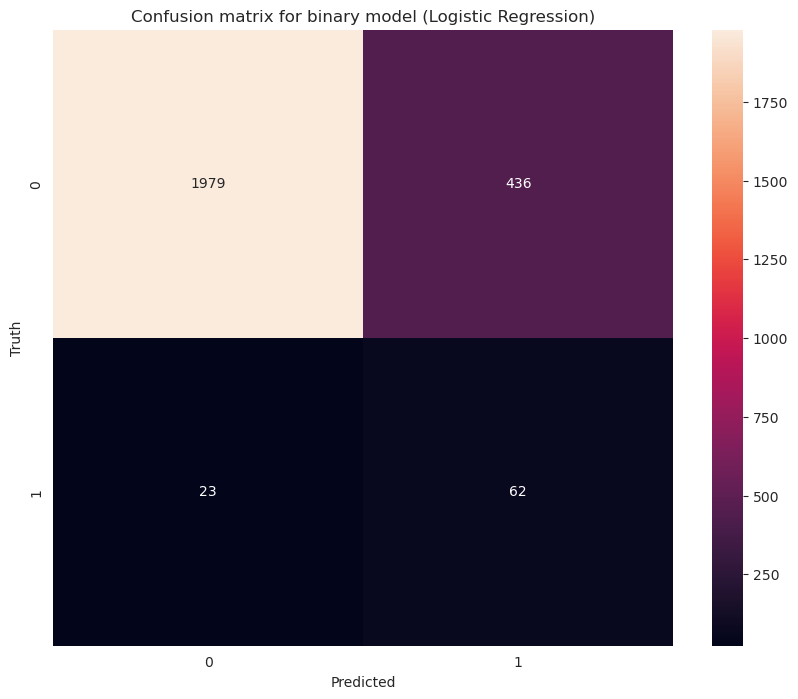

------------------------------
Binary model (XGBoost) score: 0.9712
------------------------------
Binary model classification report (XGBoost):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2415
           1       0.55      0.80      0.65        85

    accuracy                           0.97      2500
   macro avg       0.77      0.89      0.82      2500
weighted avg       0.98      0.97      0.97      2500

------------------------------


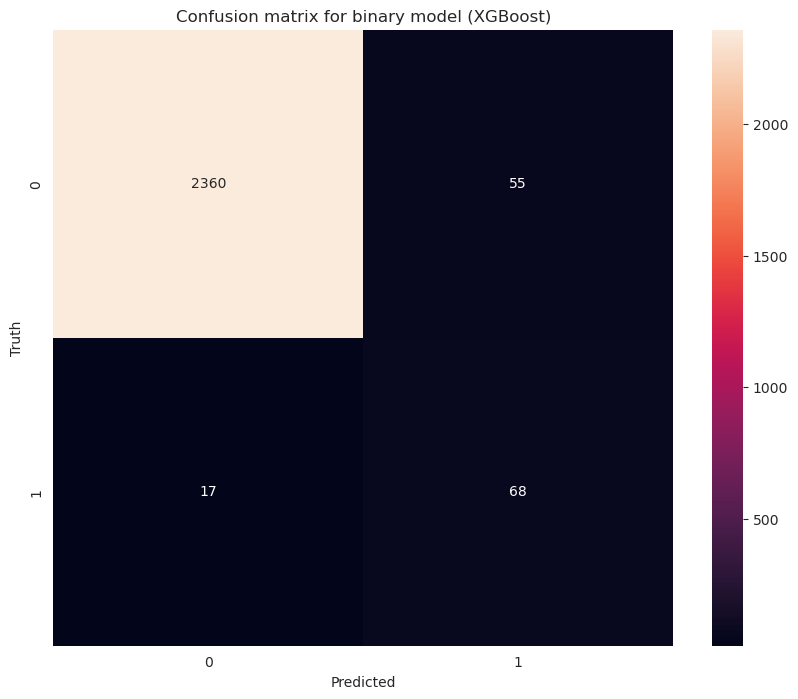

------------------------------
Multi-class model (Random Forest) score: 0.9168
------------------------------
Multi-class classification model classification report (Random Forest):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.00      0.00      0.00        28
              No Failure       0.97      0.95      0.96      2413
      Overstrain Failure       0.00      0.00      0.00        19
           Power Failure       0.03      0.04      0.04        24
         Random Failures       0.00      0.00      0.00         5
       Tool Wear Failure       0.00      0.00      0.00        11

                accuracy                           0.92      2500
               macro avg       0.17      0.17      0.17      2500
            weighted avg       0.93      0.92      0.92      2500

------------------------------


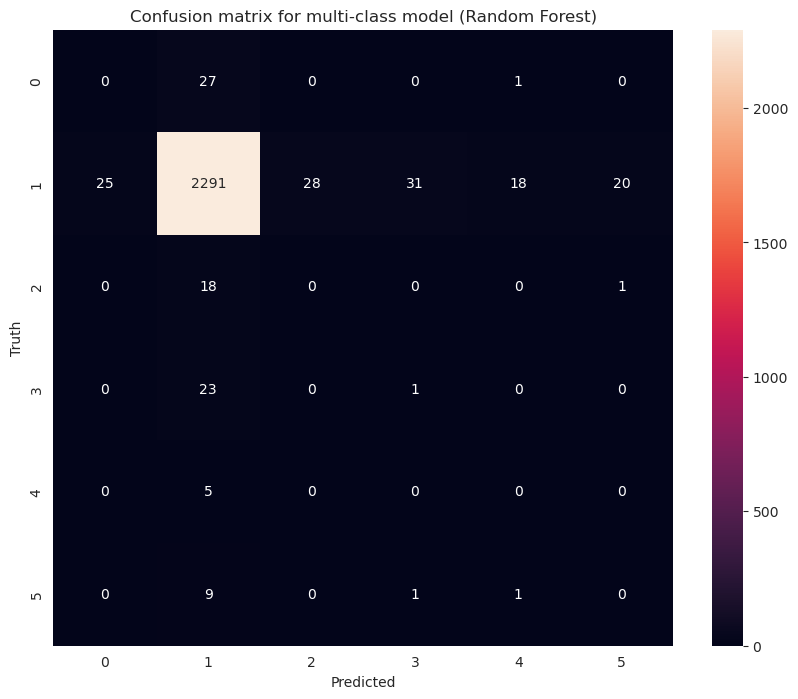

------------------------------
Multi-class model (Decision Tree) score: 0.8372
------------------------------
Multi-class classification model classification report (Decision Tree):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.00      0.00      0.00        28
              No Failure       0.96      0.87      0.91      2413
      Overstrain Failure       0.00      0.00      0.00        19
           Power Failure       0.00      0.00      0.00        24
         Random Failures       0.00      0.00      0.00         5
       Tool Wear Failure       0.00      0.00      0.00        11

                accuracy                           0.84      2500
               macro avg       0.16      0.14      0.15      2500
            weighted avg       0.93      0.84      0.88      2500

------------------------------


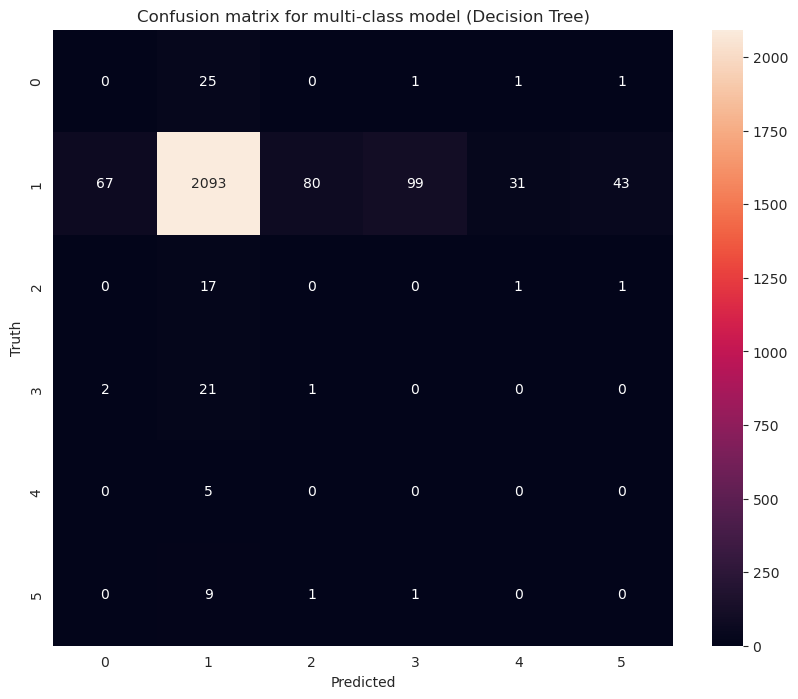

------------------------------


In [10]:
# Pipeline for the binary model (Logistic Regression)
lg_binary_model = Pipeline([
    ("preprocess", preprocess_with_scaler),
    ("smote", SMOTE()),
    ("model", LogisticRegression())
])

lg_binary_model.fit(X_train, y_train_binary)
lg_binary_model_score = lg_binary_model.score(X_test, y_test_binary)
print("Binary model (Logistic Regression) score:", lg_binary_model_score)
print("------------------------------")

lg_binary_model_predict = lg_binary_model.predict(X_test)

# Classification report for binary model (Logistic Regression)
print("Binary model classification report (Logistic Regression):")
print(classification_report(y_test_binary, lg_binary_model_predict))
print("------------------------------")

# Confusion matrix for binary model (Logistic Regression)
lg_binary_model_cm = confusion_matrix(y_test_binary, lg_binary_model_predict)
plt.figure(figsize = (10, 8))
sn.heatmap(lg_binary_model_cm, annot = True, fmt = "d")
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confusion matrix for binary model (Logistic Regression)")
plt.show()
print("------------------------------")

# Pipeline for the binary model (XGBoost)
xg_binary_model = Pipeline([
    ("preprocess", preprocess_with_scaler),
    ("smote", SMOTE()),
    ("model", XGBClassifier())
])

xg_binary_model.fit(X_train, y_train_binary)
xg_binary_model_score = xg_binary_model.score(X_test, y_test_binary)
print("Binary model (XGBoost) score:", xg_binary_model_score)
print("------------------------------")

xg_binary_model_predict = xg_binary_model.predict(X_test)

# Classification report for binary model (XGBoost)
print("Binary model classification report (XGBoost):")
print(classification_report(y_test_binary, xg_binary_model_predict))
print("------------------------------")

# Confusion matrix for binary model (XGBoost)
lg_binary_model_cm = confusion_matrix(y_test_binary, xg_binary_model_predict)
plt.figure(figsize = (10, 8))
sn.heatmap(lg_binary_model_cm, annot = True, fmt = "d")
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confusion matrix for binary model (XGBoost)")
plt.show()
print("------------------------------")

# Pipeline for the multi-class classification model (Random Forest)
rfc_multi_model = Pipeline([
    ("preprocess", preprocess_no_scaler),
    ("smote", SMOTE()),
    ("model", RandomForestClassifier())
])

rfc_multi_model.fit(X_train, y_train_multi)
rfc_multi_model_score = rfc_multi_model.score(X_test, y_test_multi)
print("Multi-class model (Random Forest) score:", rfc_multi_model_score)
print("------------------------------")

rfc_multi_model_predict = rfc_multi_model.predict(X_test)

# Classification report for multi-class classificiation model (Random Forest)
print("Multi-class classification model classification report (Random Forest):")
print(classification_report(y_test_multi, rfc_multi_model_predict))
print("------------------------------")

# Confusion matrix for muti-class classification model (Random Forest)
rfc_multi_model_cm = confusion_matrix(y_test_multi, rfc_multi_model_predict)
plt.figure(figsize = (10, 8))
sn.heatmap(rfc_multi_model_cm, annot = True, fmt = "d")
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confusion matrix for multi-class model (Random Forest)")
plt.show()
print("------------------------------")

# Pipeline for the multi-class classification model (Decision Tree)
dt_multi_model = Pipeline([
    ("preprocess", preprocess_no_scaler),
    ("smote", SMOTE()),
    ("model", DecisionTreeClassifier())
])

dt_multi_model.fit(X_train, y_train_multi)
dt_multi_model_score = dt_multi_model.score(X_test, y_test_multi)
print("Multi-class model (Decision Tree) score:", dt_multi_model_score)
print("------------------------------")

dt_multi_model_predict = dt_multi_model.predict(X_test)

# Classification report for multi-class classificiation model (Decision Tree)
print("Multi-class classification model classification report (Decision Tree):")
print(classification_report(y_test_multi, dt_multi_model_predict))
print("------------------------------")

# Confusion matrix for muti-class classification model (Decision Tree)
dt_multi_model_cm = confusion_matrix(y_test_multi, dt_multi_model_predict)
plt.figure(figsize = (10, 8))
sn.heatmap(dt_multi_model_cm, annot = True, fmt = "d")
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confusion matrix for multi-class model (Decision Tree)")
plt.show()
print("------------------------------")

Finding observations that significantly differ from the majority of the data points is the aim; in this case, these observations probably indicate anomalous machine behavior or possible failure situations that weren't clearly marked in the training data.

Following actions have been performed in this section:
- Training and Assessing models

In [11]:
# Anomaly detection
X_processed = preprocess_with_scaler.fit_transform(X)

iso = IsolationForest(contamination = 0.02)
iso_labels = iso.fit_predict(X_processed)
df["Anomaly ISO"] = (iso_labels == -1).astype(int)
print("Isolation Forest anomaly counts:")
print(df["Anomaly ISO"].value_counts())
print("------------------------------")

# ---- Local Outlier Factor ----
lof = LocalOutlierFactor(n_neighbors = 20, contamination = 0.02)
lof_labels = lof.fit_predict(X_processed)
df["Anomaly LOF"] = (lof_labels == -1).astype(int)
print("Local Outlier Factor anomaly counts:")
print(df["Anomaly LOF"].value_counts())
print("------------------------------")

Isolation Forest anomaly counts:
Anomaly ISO
0    9800
1     200
Name: count, dtype: int64
------------------------------
Local Outlier Factor anomaly counts:
Anomaly LOF
0    9800
1     200
Name: count, dtype: int64
------------------------------


## Conclusion

- In order to create a predictive maintenance system that can recognize machine faults and determine their root causes, this project effectively used machine learning techniques. The dataset had realistic sensor patterns, significant operational linkages, and a discernible imbalance in failure classes, according to thorough exploratory data analysis. To enhance model performance, appropriate preprocessing procedures were necessary, such as managing categorical variables, scaling numerical features, and using SMOTE.

- Both XGBoost and Logistic Regression were used for binary classification. Logistic Regression worked well as a basic baseline model, but XGBoost produced better accuracy and classification results, probably because of its capacity to capture nonlinear patterns and intricate feature interactions.

- Random Forest and Decision Tree models were used for multi-class failure classification. Random Forest's ability to handle heterogeneous industrial sensor data was demonstrated by the more consistent and accurate predictions it produced across the five failure categories.

- Unusual machine behaviors that might point to early-stage defects not obvious in labelled data were successfully found using anomaly detection techniques like Isolation Forest and Local Outlier Factor.

- These findings demonstrate the dataset's suitability for predictive maintenance tasks and the great potential of machine-learning-based models, particularly Random Forest for failure categorization and XGBoost for binary prediction, to support proactive maintenance strategies, lower downtime, and boost industrial efficiency.